In [3]:
from lib_analysis import *
%matplotlib inline

# Load all catalogues
# use only isolated sources
print('Loading...')
cat_lotss = isolated(Table.read('/home/fdg/phd/obs/catalogues/LoTSS_DR2_v110.srl.fits'), dist=30); cat_lotss.rename_column('Total_flux', 'flux_lotss')
print('Init:',len(cat_lotss))

cat_lolss = isolated(Table.read('../LoLSS_DR1_rolling.srl.fits'), dist=15*2); cat_lolss.rename_column('Total_flux', 'flux_lolss')
cat_8c = isolated(Table.read('/home/fdg/phd/obs/catalogues/8c.fits'), dist=60*4.5*2); cat_8c.rename_column('F_int', 'flux_8c')
cat_vlss = isolated(Table.read('/home/fdg/phd/obs/catalogues/VLSSr.fits'), dist=75*2); cat_vlss.rename_column('Total_flux', 'flux_vlss')
cat_nvss = isolated(Table.read('/home/fdg/phd/obs/catalogues/NVSS.fits'), dist=45*2); cat_nvss.rename_column('Total_flux', 'flux_nvss')
cat_gleam = isolated(Table.read('/home/fdg/phd/obs/catalogues/GLEAM_cut.fits'), dist=45*2); cat_gleam.rename_column('int_flux_fit_200', 'flux_gleam'); cat_gleam.rename_column('alpha', 'spidx_gleam')

# restrict to compact for lotss (will be used later)
snr = cat_lotss['flux_lotss']/cat_lotss['E_Total_flux']
R = 0.42+(1.08/( 1 + (snr/96.57)**(2.49) ))
cat_lotss['is_pnt'] = (R > np.log(cat_lotss['flux_lotss']/cat_lotss['Peak_flux'])) 
print('Is pnt (LoTSS) %f%%' % (100*sum(cat_lotss['is_pnt'])/len(cat_lotss)))
cat_lotss = cat_lotss[cat_lotss['is_pnt']]

cat_full = cat_lotss

# to mJy
cat_8c['flux_8c'] *= 1e3
cat_vlss['flux_vlss'] *= 1e3
cat_nvss['flux_nvss'] *= 1e3
cat_gleam['flux_gleam'] *= 1e3

# names and freqs
surveys = ['8c','lolss','vlss','lotss','gleam','nvss']
surveys_freq = np.array([38,54,74,144,200,1400])*1e6

# rms values
rms_8c = 2*1000 # mjy/b
rms_lolss = 1.6*4 # mjy/b
rms_vlss = 4*100 # mjy/b
rms_lotss = 3*100e-3 # mjy/b
rms_gleam = 10*5 # mJy/b
rms_nvss = 5*0.45 # mjy/b

# rescale rms
#rms_resc_8c = rms_8c * (144/38.)**(spidx_scale)
#rms_resc_lolss = rms_lolss * (144/54.)**(spidx_scale)
#rms_resc_vlss = rms_vlss * (144/74.)**(spidx_scale)
#rms_resc_gleam = rms_gleam * (144/200.)**(spidx_scale)
#rms_resc_nvss = rms_nvss * (144/1400.)**(spidx_scale)

print('Matching....')

# 8c
cat_full = cross_match(cat_full, cat_8c, columns_to_keep=['flux_8c'], dist=30)
print('Match 8c: %i' % sum(cat_full['flux_8c'] != 0))

# LoLSS
cat_full = cross_match(cat_full, cat_lolss, columns_to_keep=['flux_lolss'], dist=5)
print('Match LoLSS: %i' % sum(cat_full['flux_lolss'] != 0))

# VLSS
cat_full = cross_match(cat_full, cat_vlss, columns_to_keep=['flux_vlss'], dist=20)
print('Match VLSSr: %i' % sum(cat_full['flux_vlss'] != 0))

# Gleam
cat_full = cross_match(cat_full, cat_gleam, columns_to_keep=['flux_gleam'], dist=20)
print('Match GLEAM: %i' % sum(cat_full['flux_gleam'] != 0))

# NVSS
cat_full = cross_match(cat_full, cat_nvss, columns_to_keep=['flux_nvss'], dist=10)
print('Match NVSS: %i' % sum(cat_full['flux_nvss'] != 0))

# spidx
cat_full['spidx'] = 0.
idx = (cat_full['flux_nvss'] != 0)
cat_full['spidx'][idx] = np.log10(cat_full['flux_lotss'][idx]/cat_full['flux_nvss'][idx])/np.log10(144/1400.)
print('With spidx:',sum(cat_full['spidx'] != 0))

# write
cat_full.write('LoTSS_matched.fits', overwrite=True)

Loading...
Removing 951283 out of 4396228 source
Init: 3444945
Removing 339 out of 42463 source
Removing 578 out of 5859 source


Removing 4280 out of 92965 source
Removing 219240 out of 1810672 source
Removing 2 out of 50860 source
Is pnt (LoTSS) 93.250749%
Matching....
Match 8c: 201
Match LoLSS: 21010
Match VLSSr: 3966
Match GLEAM: 994
Match NVSS: 120637
With spidx: 120637


min 1100.0
8c meds: [1.26663866 1.15538182 1.22000036] avg: 1.2140069493942252
min 6.2997193
lolss meds: [1.09673185 1.07917235 1.12820239] avg: 1.1013688629243668
min 294.5698
vlss meds: [1.15678906 1.07415795 1.11926403] avg: 1.1167370136405175
min 63.39950132783602
gleam meds: [1.08276616 1.09006808 1.14623628] avg: 1.1063568382756832


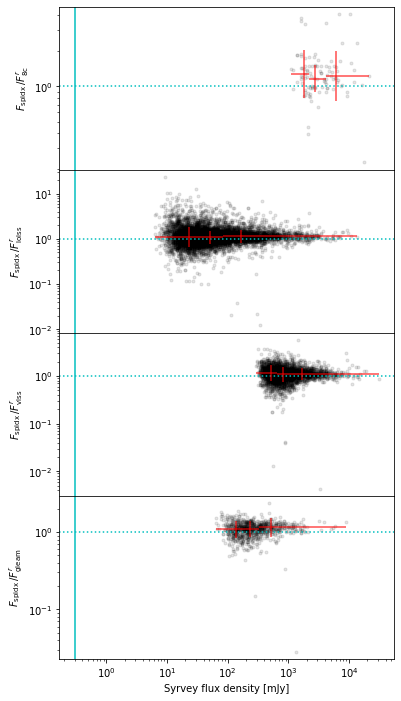

In [4]:
from lib_analysis import *
%matplotlib inline

def binning(x, y, nbins, log=True):
    """
    returns:
    1. bin centers
    2. bin median value
    3. size of the bin to be used for xerr
    4. bin_std to be used for yerr
    """
    import scipy.stats as stats
    bins = stats.mstats.mquantiles(x, np.linspace(0,1,nbins+1))
    print('min', np.min(x))
    bin_med, bin_edges, binnumber = stats.binned_statistic(x, y, statistic='median', bins=bins)
    if log: bin_std, bin_edges, binnumber = stats.binned_statistic(x, np.log(y), statistic='std', bins=bins) # in log to make input of std() symmetric
    else: bin_std, bin_edges, binnumber = stats.binned_statistic(x, y, statistic='std', bins=bins) # in log to make input of std() symmetric
    bin_centers, bin_edges, binnumber = stats.binned_statistic(x, x, statistic='median', bins=bins)
    bin_xsize = [[bin_centers[i]-bin_edges[i],bin_edges[i+1]-bin_centers[i]] for i in range(len(bin_centers))]
    bin_xsize = list(map(list, zip(*bin_xsize))) # transpose
    bin_std = [np.abs(np.exp(np.log(bin_med)-bin_std)-bin_med),np.abs(np.exp(np.log(bin_med)+bin_std)-bin_med)] # propagation of the interval (not error)
    return bin_centers, bin_med, bin_xsize, bin_std

####################################################
# ratios

cat_full = Table.read('LoTSS_matched.fits')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, figsize=(6,12), sharex=True)
fig.subplots_adjust(hspace=0)

def add_plot(survey, freq, ax):
    idx = (cat_full['flux_'+survey] != 0) & (cat_full['spidx'] != 0)
    ax.set_ylabel(r'$F_{\rm spidx}\,/F^r_{\rm %s}$' % survey)
    x = cat_full['flux_'+survey][idx]
    #x = cat_full['flux_lotss'][idx]
    y = (cat_full['flux_lotss'][idx]*(freq/144.)**(cat_full['spidx'][idx]))/(cat_full['flux_'+survey][idx])
    ax.plot( x, y, '.k', alpha=0.1 )
    #ax1.plot([rms_resc_8c*10,rms_resc_8c/10],[1/10,10], ls='-', color='c')
    ax.axvline(rms_lotss, ls='-', color='c')
    bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=3)
    print(survey, 'meds:', bin_med, 'avg:', np.nanmean(bin_med))
    ax.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.7)
    ax.axhline(1, ls=':', color='c')
    ax.set_xscale('log')
    ax.set_yscale('log')
    #ax.set_ylim(0.5,2)

add_plot('8c', 38., ax1)
add_plot('lolss', 54., ax2)
add_plot('vlss', 74., ax3)
add_plot('gleam', 200., ax4)
   
#ax4.set_xlim(1,1e5)
ax4.set_xlabel(r'Syrvey flux density [mJy]')
fig.savefig('lotss_flux.png', bbox_inches='tight')